# Comparaison des Méthodes de Parcellisation Dyadique

Ce notebook compare les différentes méthodes de parcellisation disponibles dans AntakIA :

1. **AntakIA Native** - Auto-clustering ToMATo sur projection 3D
2. **HDBSCAN Dyadique** - Density-based clustering
3. **ToMATo Dyadique** - Topological mode analysis
4. **MGE** - Multi-Granularity Ensemble
5. **Consensus** - Consensus multi-vue
6. **Ensemble** - Méta-méthode (noyaux stables)

**Dataset** : California Housing (avec coordonnées géographiques)

---

In [1]:
# Configuration du path
import sys
from pathlib import Path

# Ajouter le path source AntakIA
antakia_src = Path().absolute().parent / "src"
if str(antakia_src) not in sys.path:
    sys.path.insert(0, str(antakia_src))

print(f"✓ Path configuré: {antakia_src}")

✓ Path configuré: /Users/david/Documents/2_Code/artist-maturation/antakia/src


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports chargés")

✓ Imports chargés


## 1. Chargement des données et calcul SHAP

In [3]:
# Charger California Housing
housing = fetch_california_housing()
X_full = pd.DataFrame(housing.data, columns=housing.feature_names)
y_full = housing.target

# Sous-échantillon pour rapidité
np.random.seed(42)
sample_idx = np.random.choice(len(X_full), size=2000, replace=False)
X = X_full.iloc[sample_idx].reset_index(drop=True)
y = y_full[sample_idx]

print(f"Dataset: {X.shape[0]} observations, {X.shape[1]} features")
print(f"Features: {list(X.columns)}")
print(f"\nCoordonnées géographiques:")
print(f"  Latitude:  [{X['Latitude'].min():.2f}, {X['Latitude'].max():.2f}]")
print(f"  Longitude: [{X['Longitude'].min():.2f}, {X['Longitude'].max():.2f}]")

Dataset: 2000 observations, 8 features
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Coordonnées géographiques:
  Latitude:  [32.54, 41.81]
  Longitude: [-124.19, -114.58]


In [4]:
# Entraîner un modèle Random Forest
print("Entraînement du modèle...")
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X, y)

# Score
score = model.score(X, y)
print(f"✓ Modèle entraîné (R² = {score:.3f})")

Entraînement du modèle...
✓ Modèle entraîné (R² = 0.927)


In [5]:
# Calcul des valeurs SHAP
print("Calcul des valeurs SHAP...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Espace dyadique
X_vs = X.values  # Values Space
X_es = shap_values  # Explanations Space
feature_names = list(X.columns)

print(f"✓ SHAP calculé")
print(f"  VS shape: {X_vs.shape}")
print(f"  ES shape: {X_es.shape}")

Calcul des valeurs SHAP...
✓ SHAP calculé
  VS shape: (2000, 8)
  ES shape: (2000, 8)


## 2. Application de toutes les méthodes de parcellisation

In [6]:
from antakia.parcellation import parcellate

# Dictionnaire pour stocker les résultats
results = {}

# Liste des méthodes à tester
methods = [
    ('antakia', 'AntakIA Native', {'n_clusters': 'auto'}),
    ('hdbscan', 'HDBSCAN Dyadique', {'strategy': 'weighted', 'alpha': 0.5}),
    ('tomato', 'ToMATo Dyadique', {'merge_threshold': 0.1}),
    ('mge', 'MGE', {'k_range': (3, 10), 'n_granularities': 5}),
    ('consensus', 'Consensus', {'k_values': [3, 5, 7]}),
]

In [7]:
# Appliquer chaque méthode
for method_id, method_name, kwargs in methods:
    print(f"\n{'='*60}")
    print(f"Méthode: {method_name}")
    print(f"{'='*60}")
    
    try:
        result = parcellate(
            X_vs, X_es,
            method=method_id,
            verbose=True,
            min_parcelle_size=30,
            **kwargs
        )
        results[method_id] = {
            'name': method_name,
            'result': result,
            'labels': result.labels,
            'n_parcelles': result.n_parcelles,
            'dyadic_score': result.dyadic_score
        }
        print(f"\n→ {result.n_parcelles} parcelles, Score dyadique: {result.dyadic_score:.3f}")
    except Exception as e:
        print(f"⚠️ Erreur: {e}")
        results[method_id] = None


Méthode: AntakIA Native
════════════════════════════════════════════════════════════
AntakIA Auto-Clustering (tomato) (10D)
════════════════════════════════════════════════════════════
[1/3] Pas de projection nécessaire (dim ≤ 10)
[2/3] Initialisation AutoCluster...
[3/3] Clustering (n_clusters=auto)...
   Progress: 0%
   Progress: 80%
   Progress: 100%

✓ AntakIA Auto-Clustering terminé : 3 parcelles

→ 3 parcelles, Score dyadique: 0.000

Méthode: HDBSCAN Dyadique
════════════════════════════════════════════════════════════
HDBSCAN Dyadique (stratégie: weighted)
════════════════════════════════════════════════════════════
   Utilisation CPU (hdbscan)...

✓ HDBSCAN terminé : 2 parcelles

→ 2 parcelles, Score dyadique: 0.003

Méthode: ToMATo Dyadique
════════════════════════════════════════════════════════════
ToMATo Dyadique (Topological Mode Analysis)
════════════════════════════════════════════════════════════
[1/3] Réduction de dimension (UMAP)...
[2/3] Fusion dyadique...
   Dimens

## 3. Tableau comparatif

In [8]:
# Créer le tableau comparatif
comparison_data = []

for method_id, data in results.items():
    if data is not None:
        r = data['result']
        comparison_data.append({
            'Méthode': data['name'],
            'Parcelles': r.n_parcelles,
            'Silhouette VS': f"{r.silhouette_vs:.3f}",
            'Silhouette ES': f"{r.silhouette_es:.3f}",
            'Score Dyadique': f"{r.dyadic_score:.3f}",
            'Consistance': f"{r.consistency_vs_es:.3f}",
            'Bruit (%)': f"{(r.labels == -1).sum() / len(r.labels) * 100:.1f}"
        })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Score Dyadique', ascending=False)

print("\n" + "="*80)
print("TABLEAU COMPARATIF DES MÉTHODES DE PARCELLISATION")
print("="*80)
display(df_comparison)


TABLEAU COMPARATIF DES MÉTHODES DE PARCELLISATION


,Méthode,Parcelles,Silhouette VS,Silhouette ES,Score Dyadique,Consistance,Bruit (%)
1,HDBSCAN Dyadique,2,0.002,0.241,0.003,-0.000,50.3
0,AntakIA Native,3,-0.024,0.104,0.000,-0.009,5.8
2,ToMATo Dyadique,31,-0.202,-0.204,0.000,0.004,0.0
3,MGE,4,-0.210,0.078,0.000,-0.007,0.0
4,Consensus,4,-0.218,0.147,0.000,-0.007,0.0


## 4. Méta-méthode : Parcellisation Ensembliste (Noyaux Stables)

In [9]:
def compute_stability_matrix(results_dict, n_samples):
    """
    Calcule la matrice de stabilité entre toutes les paires de points.
    
    S[i,j] = proportion de méthodes où i et j sont dans le même cluster
    """
    # Collecter tous les labels valides
    all_labels = []
    method_names = []
    
    for method_id, data in results_dict.items():
        if data is not None:
            all_labels.append(data['labels'])
            method_names.append(data['name'])
    
    n_methods = len(all_labels)
    print(f"Calcul de la matrice de stabilité sur {n_methods} méthodes...")
    
    # Matrice de co-association
    coassoc = np.zeros((n_samples, n_samples))
    valid_counts = np.zeros((n_samples, n_samples))
    
    for labels in all_labels:
        # Pour chaque cluster (hors bruit)
        for c in set(labels):
            if c == -1:
                continue
            mask = labels == c
            idx = np.where(mask)[0]
            # Points dans le même cluster
            coassoc[np.ix_(idx, idx)] += 1
        
        # Compter les méthodes valides (non bruit) pour chaque paire
        valid_mask = labels != -1
        valid_idx = np.where(valid_mask)[0]
        valid_counts[np.ix_(valid_idx, valid_idx)] += 1
    
    # Normaliser
    stability = np.zeros_like(coassoc)
    mask = valid_counts > 0
    stability[mask] = coassoc[mask] / valid_counts[mask]
    
    return stability, method_names


def extract_stable_cores(stability_matrix, threshold=0.75, min_core_size=10):
    """
    Extrait les noyaux stables de la matrice de stabilité.
    
    Un noyau = ensemble de points qui sont TOUJOURS (ou presque) ensemble.
    """
    n_samples = len(stability_matrix)
    
    # Points déjà assignés
    assigned = np.zeros(n_samples, dtype=bool)
    cores = []
    
    # Trouver les noyaux par clustering hiérarchique sur 1 - stabilité
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform
    
    # Distance = 1 - stabilité
    dist = 1 - stability_matrix
    np.fill_diagonal(dist, 0)
    
    # Linkage
    dist_condensed = squareform(dist, checks=False)
    Z = linkage(dist_condensed, method='average')
    
    # Couper à threshold
    labels = fcluster(Z, t=1-threshold, criterion='distance') - 1
    
    # Extraire les cores
    for c in set(labels):
        mask = labels == c
        if mask.sum() >= min_core_size:
            # Vérifier que c'est vraiment stable (stabilité interne élevée)
            idx = np.where(mask)[0]
            internal_stability = stability_matrix[np.ix_(idx, idx)].mean()
            if internal_stability >= threshold:
                cores.append({
                    'indices': idx,
                    'size': len(idx),
                    'internal_stability': internal_stability
                })
    
    return cores, labels


def ensemble_parcellation(results_dict, n_samples, stability_threshold=0.75, min_core_size=20):
    """
    Méta-méthode de parcellisation ensembliste.
    
    1. Calcule la matrice de stabilité
    2. Extrait les noyaux stables
    3. Assigne les points frontière au noyau le plus proche
    
    Returns
    -------
    labels : array
        Labels des parcelles
    stability_scores : array
        Score de stabilité par point (confiance)
    cores : list
        Liste des noyaux extraits
    """
    # 1. Matrice de stabilité
    stability_matrix, method_names = compute_stability_matrix(results_dict, n_samples)
    
    # 2. Extraire les noyaux
    cores, raw_labels = extract_stable_cores(
        stability_matrix, 
        threshold=stability_threshold,
        min_core_size=min_core_size
    )
    
    print(f"\n✓ {len(cores)} noyaux stables identifiés:")
    for i, core in enumerate(cores):
        print(f"  Core {i}: {core['size']} points, stabilité interne = {core['internal_stability']:.3f}")
    
    # 3. Score de stabilité par point
    # = stabilité moyenne avec les autres points du même cluster
    stability_scores = np.zeros(n_samples)
    for i in range(n_samples):
        same_cluster = raw_labels == raw_labels[i]
        if same_cluster.sum() > 1:
            stability_scores[i] = stability_matrix[i, same_cluster].mean()
    
    return raw_labels, stability_scores, cores, stability_matrix

print("✓ Fonctions d'ensemble définies")

✓ Fonctions d'ensemble définies


In [10]:
# Appliquer la méta-méthode
print("="*60)
print("PARCELLISATION ENSEMBLISTE (Noyaux Stables)")
print("="*60)

ensemble_labels, stability_scores, cores, stability_matrix = ensemble_parcellation(
    results, 
    n_samples=len(X),
    stability_threshold=0.6,
    min_core_size=30
)

# Ajouter aux résultats
n_ensemble = len(set(ensemble_labels))
results['ensemble'] = {
    'name': 'Ensemble (Noyaux)',
    'labels': ensemble_labels,
    'n_parcelles': n_ensemble,
    'stability_scores': stability_scores,
    'cores': cores
}

print(f"\n→ {n_ensemble} parcelles via méthode ensembliste")
print(f"  Stabilité moyenne: {stability_scores.mean():.3f}")
print(f"  Points très stables (>0.8): {(stability_scores > 0.8).sum()} ({(stability_scores > 0.8).mean()*100:.1f}%)")
print(f"  Points frontière (<0.5): {(stability_scores < 0.5).sum()} ({(stability_scores < 0.5).mean()*100:.1f}%)")

PARCELLISATION ENSEMBLISTE (Noyaux Stables)
Calcul de la matrice de stabilité sur 5 méthodes...

✓ 7 noyaux stables identifiés:
  Core 0: 38 points, stabilité interne = 0.772
  Core 1: 745 points, stabilité interne = 0.766
  Core 2: 163 points, stabilité interne = 0.784
  Core 3: 35 points, stabilité interne = 0.762
  Core 4: 51 points, stabilité interne = 0.754
  Core 5: 330 points, stabilité interne = 0.787
  Core 6: 593 points, stabilité interne = 0.777

→ 15 parcelles via méthode ensembliste
  Stabilité moyenne: 0.773
  Points très stables (>0.8): 427 (21.3%)
  Points frontière (<0.5): 7 (0.4%)


## 5. Visualisation comparative sur carte géographique

In [11]:
# Extraire coordonnées
lat_col = 'Latitude'
lon_col = 'Longitude'

lat_idx = feature_names.index(lat_col)
lon_idx = feature_names.index(lon_col)

latitudes = X_vs[:, lat_idx]
longitudes = X_vs[:, lon_idx]

print(f"Coordonnées extraites: Lat [{latitudes.min():.2f}, {latitudes.max():.2f}], Lon [{longitudes.min():.2f}, {longitudes.max():.2f}]")

Coordonnées extraites: Lat [32.54, 41.81], Lon [-124.19, -114.58]


In [12]:
# Créer la figure avec subplots
n_methods = len([r for r in results.values() if r is not None])
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[r['name'] for r in results.values() if r is not None],
    specs=[[{'type': 'scattergeo'} for _ in range(n_cols)] for _ in range(n_rows)],
    horizontal_spacing=0.02,
    vertical_spacing=0.08
)

# Palette de couleurs
colors = px.colors.qualitative.Set2 + px.colors.qualitative.Set3

# Ajouter chaque méthode
idx = 0
for method_id, data in results.items():
    if data is None:
        continue
    
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    labels = data['labels']
    n_parcelles = data['n_parcelles']
    
    # Couleurs par parcelle
    point_colors = [colors[l % len(colors)] if l >= 0 else 'lightgray' for l in labels]
    
    # Texte hover
    hover_text = [
        f"Parcelle: {l}<br>Prix: ${y[i]*100000:.0f}<br>Lat: {latitudes[i]:.3f}<br>Lon: {longitudes[i]:.3f}"
        for i, l in enumerate(labels)
    ]
    
    fig.add_trace(
        go.Scattergeo(
            lat=latitudes,
            lon=longitudes,
            mode='markers',
            marker=dict(
                size=4,
                color=point_colors,
                line=dict(width=0)
            ),
            text=hover_text,
            hoverinfo='text',
            name=f"{data['name']} ({n_parcelles}p)"
        ),
        row=row, col=col
    )
    
    idx += 1

# Configuration géographique - RESSERRÉ SUR LA CALIFORNIE
for i in range(1, n_rows * n_cols + 1):
    geo_key = f"geo{i}" if i > 1 else "geo"
    fig.update_layout(**{
        geo_key: dict(
            fitbounds='locations',  # Ajuste automatiquement aux données
            showland=True,
            landcolor='rgb(250, 250, 250)',
            showlakes=True,
            lakecolor='rgb(200, 220, 255)',
            showcoastlines=True,
            coastlinecolor='rgb(120, 120, 120)',
            showocean=True,
            oceancolor='rgb(220, 235, 255)',
            bgcolor='rgba(255,255,255,0)'
        )
    })

fig.update_layout(
    title=dict(
        text="<b>Comparaison des Méthodes de Parcellisation</b><br><sup>California Housing - Vision Dyadique (VS × ES)</sup>",
        x=0.5,
        font=dict(size=18)
    ),
    height=400 * n_rows,
    showlegend=False,
    margin=dict(t=100, l=20, r=20, b=20)
)

fig.show()

## 6. Visualisation de la stabilité (Méthode Ensemble)

In [13]:
# Carte de stabilité
fig_stability = go.Figure()

# Points colorés par stabilité
fig_stability.add_trace(
    go.Scattergeo(
        lat=latitudes,
        lon=longitudes,
        mode='markers',
        marker=dict(
            size=6,
            color=stability_scores,
            colorscale='RdYlGn',  # Rouge (instable) → Jaune → Vert (stable)
            cmin=0,
            cmax=1,
            colorbar=dict(
                title='Stabilité',
                tickvals=[0, 0.25, 0.5, 0.75, 1],
                ticktext=['Très instable', 'Instable', 'Frontière', 'Stable', 'Noyau']
            )
        ),
        text=[f"Stabilité: {s:.2f}<br>Parcelle: {l}<br>Prix: ${y[i]*100000:.0f}" 
              for i, (s, l) in enumerate(zip(stability_scores, ensemble_labels))],
        hoverinfo='text'
    )
)

fig_stability.update_layout(
    geo=dict(
        fitbounds='locations',  # Ajuste automatiquement aux données
        showland=True,
        landcolor='rgb(250, 250, 250)',
        showlakes=True,
        lakecolor='rgb(200, 220, 255)',
        showcoastlines=True,
        coastlinecolor='rgb(120, 120, 120)',
        showocean=True,
        oceancolor='rgb(220, 235, 255)'
    )
)

fig_stability.update_layout(
    title=dict(
        text="<b>Carte de Stabilité - Parcellisation Ensembliste</b><br><sup>Vert = Point toujours dans le même cluster | Rouge = Point frontière instable</sup>",
        x=0.5
    ),
    height=600
)

fig_stability.show()

In [14]:
# Distribution de la stabilité
fig_hist = go.Figure()

fig_hist.add_trace(
    go.Histogram(
        x=stability_scores,
        nbinsx=30,
        marker_color='steelblue',
        opacity=0.7
    )
)

# Lignes de seuil
fig_hist.add_vline(x=0.5, line_dash="dash", line_color="orange", 
                   annotation_text="Frontière", annotation_position="top")
fig_hist.add_vline(x=0.75, line_dash="dash", line_color="green",
                   annotation_text="Stable", annotation_position="top")

fig_hist.update_layout(
    title="Distribution des scores de stabilité",
    xaxis_title="Score de stabilité",
    yaxis_title="Nombre de points",
    height=400
)

fig_hist.show()

## 7. Matrice de stabilité (heatmap)

Génération de la Heatmap + ACH (Clustering Hiérarchique)...


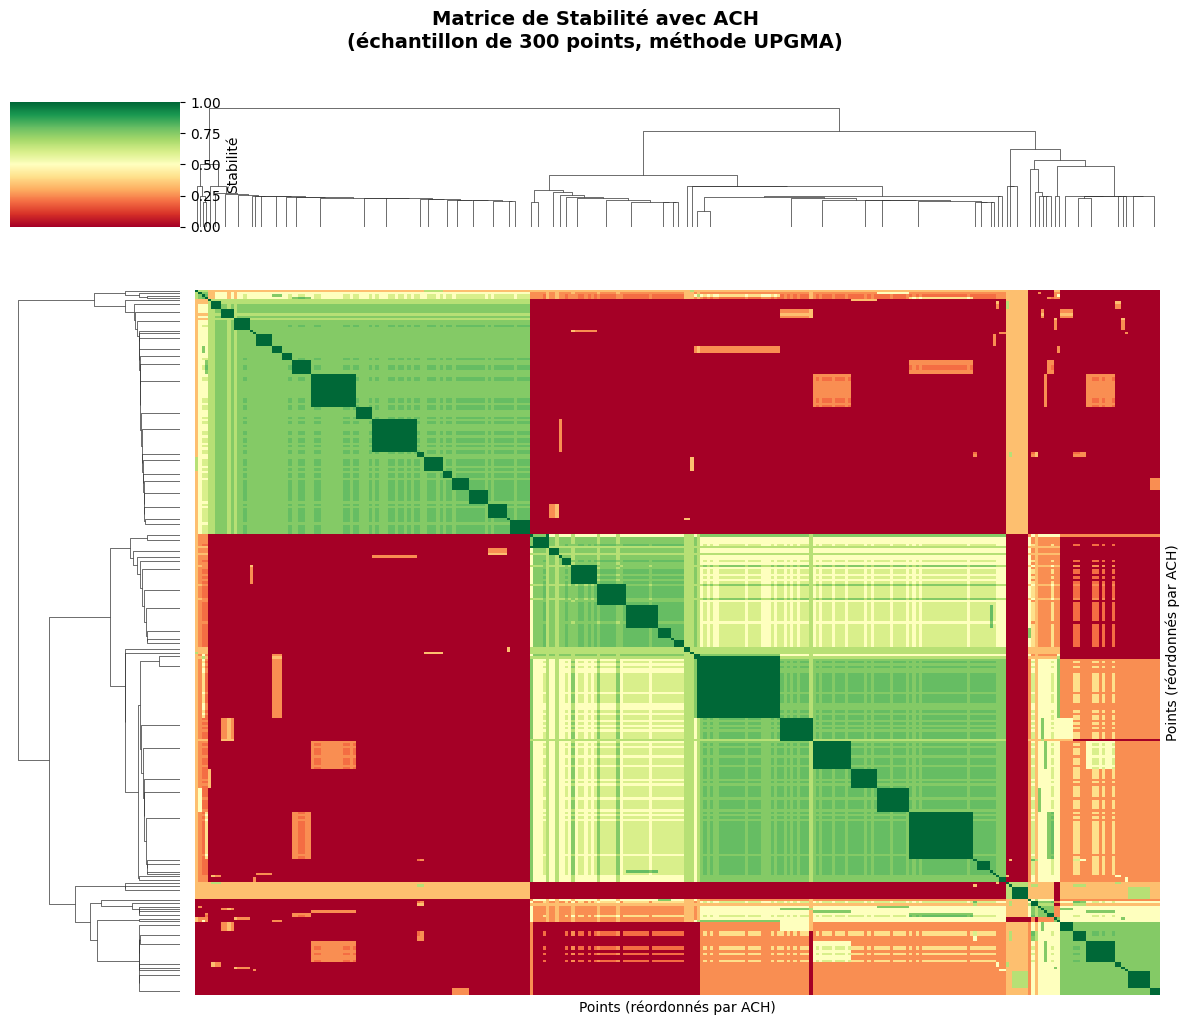


✓ ACH révèle 9 groupes naturels (seuil=0.4)
  Les blocs diagonaux verts indiquent des clusters STABLES
  Les zones rouges/jaunes indiquent des FRONTIÈRES entre clusters


In [15]:
# ============================================================
# HEATMAP + ACH (Clustering Hiérarchique) de la matrice de stabilité
# ============================================================
# Technique : clustermap seaborn avec dendrogramme
# Révèle la structure naturelle des groupements stables

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Sous-échantillon pour visualisation (matrice n×n trop grande)
sample_size = 300
np.random.seed(42)
sample_idx_viz = np.random.choice(len(X), size=sample_size, replace=False)
sample_idx_viz = np.sort(sample_idx_viz)

stability_sample = stability_matrix[np.ix_(sample_idx_viz, sample_idx_viz)]

# Convertir stabilité (similarité) en distance pour le clustering
# Distance = 1 - Stabilité
distance_matrix = 1 - stability_sample
np.fill_diagonal(distance_matrix, 0)  # Diagonale à 0

# Clustering hiérarchique (linkage) sur les points
# Méthode 'average' (UPGMA) pour des clusters équilibrés
linkage_matrix = linkage(squareform(distance_matrix), method='average')

# Clustermap avec seaborn
print("Génération de la Heatmap + ACH (Clustering Hiérarchique)...")
g = sns.clustermap(
    stability_sample,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    figsize=(12, 10),
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    xticklabels=False,
    yticklabels=False
)

# Personnalisation
g.fig.suptitle(
    f'Matrice de Stabilité avec ACH\n'
    f'(échantillon de {sample_size} points, méthode UPGMA)',
    y=1.02, fontsize=14, fontweight='bold'
)
g.ax_cbar.set_ylabel('Stabilité', fontsize=10)

# Annotations
g.ax_heatmap.set_xlabel('Points (réordonnés par ACH)', fontsize=10)
g.ax_heatmap.set_ylabel('Points (réordonnés par ACH)', fontsize=10)

plt.tight_layout()
plt.show()

# Extraire l'ordre des points après ACH
order_ach = g.dendrogram_row.reordered_ind
print(f"\n✓ ACH révèle {len(set(fcluster(linkage_matrix, t=0.4, criterion='distance')))} groupes naturels (seuil=0.4)")
print(f"  Les blocs diagonaux verts indiquent des clusters STABLES")
print(f"  Les zones rouges/jaunes indiquent des FRONTIÈRES entre clusters")

In [16]:
# ============================================================
# EXPLORATION INTERACTIVE : Sélection dans la matrice → Carte
# ============================================================
# Permet de sélectionner des groupes de points et les voir sur la carte

from ipywidgets import interact, IntRangeSlider, Output, HBox, VBox
import ipywidgets as widgets

# Récupérer l'ordre ACH pour mapper indices matrice → indices originaux
order_ach = g.dendrogram_row.reordered_ind
sample_to_original = sample_idx_viz[order_ach]  # Indices originaux réordonnés

# Créer les widgets
range_slider = IntRangeSlider(
    value=[0, 50],
    min=0,
    max=sample_size-1,
    step=1,
    description='Plage ACH:',
    continuous_update=False,
    layout=widgets.Layout(width='500px')
)

output_map = Output()
output_stats = Output()

def update_selection(change):
    """Met à jour la carte quand la sélection change."""
    start, end = range_slider.value
    
    # Indices dans l'échantillon (ordre ACH)
    selected_ach_indices = list(range(start, end + 1))
    
    # Convertir en indices originaux
    selected_original = sample_to_original[selected_ach_indices]
    
    with output_stats:
        output_stats.clear_output(wait=True)
        print(f"📊 Sélection : indices ACH [{start}, {end}] → {len(selected_original)} points")
        print(f"   Stabilité moyenne intra-groupe: {stability_sample[start:end+1, start:end+1].mean():.3f}")
        
        # Labels des points sélectionnés
        selected_labels = ensemble_labels[selected_original]
        unique_labels, counts = np.unique(selected_labels, return_counts=True)
        print(f"   Parcelles représentées:")
        for lbl, cnt in zip(unique_labels, counts):
            print(f"      Parcelle {lbl}: {cnt} points ({cnt/len(selected_original)*100:.1f}%)")
    
    with output_map:
        output_map.clear_output(wait=True)
        
        # Créer la carte
        fig_select = go.Figure()
        
        # Tous les points en gris
        fig_select.add_trace(go.Scattergeo(
            lat=latitudes,
            lon=longitudes,
            mode='markers',
            marker=dict(size=4, color='lightgray', opacity=0.3),
            name='Autres points',
            hoverinfo='skip'
        ))
        
        # Points sélectionnés en couleur
        fig_select.add_trace(go.Scattergeo(
            lat=latitudes[selected_original],
            lon=longitudes[selected_original],
            mode='markers',
            marker=dict(
                size=8,
                color=stability_scores[selected_original],
                colorscale='RdYlGn',
                cmin=0, cmax=1,
                colorbar=dict(title='Stabilité', x=1.02)
            ),
            text=[f"Idx: {i}<br>Parcelle: {ensemble_labels[i]}<br>Stab: {stability_scores[i]:.2f}" 
                  for i in selected_original],
            hoverinfo='text',
            name=f'Sélection ({len(selected_original)} pts)'
        ))
        
        fig_select.update_layout(
            title=f"Points sélectionnés dans la matrice ACH [{start}:{end}]",
            geo=dict(
                fitbounds='locations',
                showland=True,
                landcolor='rgb(250, 250, 250)',
                showcoastlines=True,
                showocean=True,
                oceancolor='rgb(220, 235, 255)'
            ),
            height=500,
            showlegend=True
        )
        
        fig_select.show()

# Connecter le slider
range_slider.observe(update_selection, names='value')

# Afficher l'interface
print("🔍 EXPLORATION INTERACTIVE")
print("=" * 50)
print("Déplacez le slider pour sélectionner une plage de points")
print("dans l'ordre ACH (matrice de stabilité)")
print()

display(VBox([range_slider, output_stats, output_map]))

# Déclencher l'affichage initial
update_selection(None)

🔍 EXPLORATION INTERACTIVE
Déplacez le slider pour sélectionner une plage de points
dans l'ordre ACH (matrice de stabilité)



In [17]:
# ============================================================
# VERSION SIMPLE : Fonction pour explorer une plage ACH
# ============================================================
# Si les widgets ne fonctionnent pas, utilisez cette fonction

def explore_ach_range(start: int, end: int, show_stability_detail: bool = False):
    """
    Affiche les points correspondant à une plage d'indices ACH sur la carte.
    
    Parameters
    ----------
    start, end : int
        Indices dans l'ordre ACH (0 à sample_size-1)
    show_stability_detail : bool
        Afficher la sous-matrice de stabilité
    
    Example
    -------
    >>> explore_ach_range(0, 50)      # Premier bloc
    >>> explore_ach_range(150, 200)   # Milieu
    >>> explore_ach_range(250, 299)   # Dernier bloc
    """
    # Validation
    start = max(0, min(start, sample_size - 1))
    end = max(start, min(end, sample_size - 1))
    
    # Indices dans l'ordre ACH → indices originaux
    selected_ach = list(range(start, end + 1))
    selected_original = sample_to_original[selected_ach]
    
    print(f"📍 Plage ACH [{start}, {end}] → {len(selected_original)} points")
    print()
    
    # Statistiques
    sub_stability = stability_sample[start:end+1, start:end+1]
    print(f"📊 Stabilité intra-groupe:")
    print(f"   Moyenne: {sub_stability.mean():.3f}")
    print(f"   Min: {sub_stability.min():.3f}, Max: {sub_stability.max():.3f}")
    print()
    
    # Distribution des parcelles
    selected_labels = ensemble_labels[selected_original]
    unique_labels, counts = np.unique(selected_labels, return_counts=True)
    print(f"📦 Parcelles représentées:")
    for lbl, cnt in sorted(zip(unique_labels, counts), key=lambda x: -x[1]):
        pct = cnt / len(selected_original) * 100
        bar = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"   Parcelle {lbl:2d}: {bar} {cnt:3d} pts ({pct:5.1f}%)")
    print()
    
    # Carte
    fig = go.Figure()
    
    # Fond : tous les points en gris
    fig.add_trace(go.Scattergeo(
        lat=latitudes,
        lon=longitudes,
        mode='markers',
        marker=dict(size=3, color='lightgray', opacity=0.2),
        name='Tous les points',
        hoverinfo='skip'
    ))
    
    # Points sélectionnés colorés par stabilité
    fig.add_trace(go.Scattergeo(
        lat=latitudes[selected_original],
        lon=longitudes[selected_original],
        mode='markers',
        marker=dict(
            size=10,
            color=stability_scores[selected_original],
            colorscale='RdYlGn',
            cmin=0, cmax=1,
            colorbar=dict(title='Stabilité'),
            line=dict(width=1, color='black')
        ),
        text=[f"Point {i}<br>Parcelle: {ensemble_labels[i]}<br>Stabilité: {stability_scores[i]:.2f}<br>Prix: ${y[i]*100000:.0f}" 
              for i in selected_original],
        hoverinfo='text',
        name=f'Sélection ACH [{start}:{end}]'
    ))
    
    fig.update_layout(
        title=f"<b>Points sélectionnés dans la matrice ACH [{start}:{end}]</b><br>"
              f"<sup>{len(selected_original)} points, stabilité moy. = {sub_stability.mean():.2f}</sup>",
        geo=dict(
            fitbounds='locations',
            showland=True,
            landcolor='rgb(250, 250, 250)',
            showcoastlines=True,
            coastlinecolor='rgb(100, 100, 100)',
            showocean=True,
            oceancolor='rgb(220, 235, 255)'
        ),
        height=750,
        showlegend=True
    )
    
    fig.show()
    
    # Optionnel : afficher la sous-matrice
    if show_stability_detail:
        print("\n📈 Sous-matrice de stabilité:")
        fig_sub = go.Figure(go.Heatmap(
            z=sub_stability,
            colorscale='RdYlGn',
            zmin=0, zmax=1
        ))
        fig_sub.update_layout(
            title=f"Stabilité intra-groupe [{start}:{end}]",
            height=400, width=500
        )
        fig_sub.show()

print("✅ Fonction explore_ach_range() définie")
print()
print("Exemples d'utilisation:")
print("  explore_ach_range(0, 80)       # Premier grand bloc (haut-gauche)")
print("  explore_ach_range(100, 180)    # Zone centrale")  
print("  explore_ach_range(220, 299)    # Dernier bloc (bas-droite)")
print()
print("Avec détail de stabilité:")
print("  explore_ach_range(0, 50, show_stability_detail=True)")

✅ Fonction explore_ach_range() définie

Exemples d'utilisation:
  explore_ach_range(0, 80)       # Premier grand bloc (haut-gauche)
  explore_ach_range(100, 180)    # Zone centrale
  explore_ach_range(220, 299)    # Dernier bloc (bas-droite)

Avec détail de stabilité:
  explore_ach_range(0, 50, show_stability_detail=True)


In [18]:
# ============================================================
# EXEMPLE : Explorer le premier bloc stable (haut-gauche de la matrice)
# ============================================================

explore_ach_range(0, 80)

📍 Plage ACH [0, 80] → 81 points

📊 Stabilité intra-groupe:
   Moyenne: 0.323
   Min: 0.000, Max: 1.000

📦 Parcelles représentées:
   Parcelle  3: ███████████████████░  77 pts ( 95.1%)
   Parcelle  2: ░░░░░░░░░░░░░░░░░░░░   4 pts (  4.9%)



In [19]:
# ============================================================
# EXEMPLE : Explorer le deuxième bloc stable (bas-droite de la matrice)
# ============================================================

explore_ach_range(200, 299)

📍 Plage ACH [200, 299] → 100 points

📊 Stabilité intra-groupe:
   Moyenne: 0.328
   Min: 0.000, Max: 1.000

📦 Parcelles représentées:
   Parcelle 13: ██████████░░░░░░░░░░  51 pts ( 51.0%)
   Parcelle  7: ██████░░░░░░░░░░░░░░  31 pts ( 31.0%)
   Parcelle  8: █░░░░░░░░░░░░░░░░░░░   7 pts (  7.0%)
   Parcelle  1: █░░░░░░░░░░░░░░░░░░░   6 pts (  6.0%)
   Parcelle 10: ░░░░░░░░░░░░░░░░░░░░   2 pts (  2.0%)
   Parcelle  0: ░░░░░░░░░░░░░░░░░░░░   1 pts (  1.0%)
   Parcelle  9: ░░░░░░░░░░░░░░░░░░░░   1 pts (  1.0%)
   Parcelle 12: ░░░░░░░░░░░░░░░░░░░░   1 pts (  1.0%)



In [20]:
# ============================================================
# COUPE DU DENDROGRAMME : Slider sur le seuil de distance
# ============================================================
# COULEURS STABLES basées sur la position dans le dendrogramme
# Rouge = gauche, Jaune = centre, Bleu = droite

from scipy.cluster.hierarchy import fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.colors as mcolors

# Rappel : linkage_matrix contient la hiérarchie de fusion
# linkage_matrix[i] = [idx1, idx2, distance, n_points]

# Afficher les distances de fusion pour comprendre l'échelle
distances = linkage_matrix[:, 2]
print("📊 Statistiques des distances de fusion (linkage matrix Z):")
print(f"   Min: {distances.min():.3f}")
print(f"   Max: {distances.max():.3f}")
print(f"   Médiane: {np.median(distances):.3f}")
print(f"   Quartiles: Q1={np.percentile(distances, 25):.3f}, Q3={np.percentile(distances, 75):.3f}")
print()

# Position normalisée de chaque point dans l'ordre ACH (0 à 1)
# Utilisé pour des couleurs STABLES
position_ach_norm = np.zeros(sample_size)
for i, idx in enumerate(order_ach):
    position_ach_norm[idx] = i / (sample_size - 1)  # 0 à 1

# Colormap spectrale
cmap_spectral = plt.cm.get_cmap('Spectral')

def get_stable_color(cluster_labels, clust_id, position_norm):
    """Couleur basée sur la position moyenne dans le dendrogramme."""
    mask = cluster_labels == clust_id
    mean_pos = position_norm[mask].mean()
    rgba = cmap_spectral(mean_pos)
    return mcolors.rgb2hex(rgba[:3]), mean_pos

# Fonction pour couper et visualiser
def cut_dendrogram_and_map(threshold: float, show_dendrogram: bool = False):
    """
    Coupe le dendrogramme au seuil donné et affiche les clusters sur la carte.
    
    COULEURS STABLES : basées sur la position dans le dendrogramme.
    - Rouge/Orange = clusters à gauche
    - Jaune/Vert = clusters au centre  
    - Bleu/Violet = clusters à droite
    
    Parameters
    ----------
    threshold : float
        Seuil de distance pour fcluster (0 à 1 environ)
    show_dendrogram : bool
        Afficher le dendrogramme avec la ligne de coupe
    """
    # Couper le dendrogramme
    cluster_labels_ach = fcluster(linkage_matrix, t=threshold, criterion='distance')
    n_clusters = len(set(cluster_labels_ach))
    
    print(f"✂️  Seuil de coupe: {threshold:.3f}")
    print(f"   → {n_clusters} clusters générés")
    print()
    
    # Calculer position moyenne et couleur de chaque cluster
    cluster_info = {}
    for clust_id in set(cluster_labels_ach):
        hex_color, mean_pos = get_stable_color(cluster_labels_ach, clust_id, position_ach_norm)
        mask = cluster_labels_ach == clust_id
        cluster_info[clust_id] = {
            'color': hex_color,
            'position': mean_pos,
            'size': mask.sum()
        }
    
    # Trier par position (gauche à droite)
    sorted_clusters = sorted(cluster_info.keys(), key=lambda c: cluster_info[c]['position'])
    
    # Distribution des clusters
    print(f"📦 Distribution des {n_clusters} clusters (triés par position ACH):")
    for clust_id in sorted_clusters[:10]:
        info = cluster_info[clust_id]
        pct = info['size'] / sample_size * 100
        pos_pct = info['position'] * 100
        bar = "█" * int(pct / 3) + "░" * (33 - int(pct / 3))
        print(f"   C{clust_id:2d} [{pos_pct:3.0f}%]: {bar} {info['size']:3d} pts ({pct:5.1f}%)")
    if n_clusters > 10:
        print(f"   ... et {n_clusters - 10} autres clusters")
    print()
    
    # Optionnel : dendrogramme avec ligne de coupe
    if show_dendrogram:
        fig_dend, ax = plt.subplots(figsize=(12, 4))
        dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=threshold)
        ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil = {threshold:.3f}')
        ax.set_title(f'Dendrogramme avec coupe à t={threshold:.3f} → {n_clusters} clusters')
        ax.set_ylabel('Distance')
        ax.legend()
        plt.tight_layout()
        plt.show()
    
    # Carte avec les clusters (couleurs stables)
    fig = go.Figure()
    
    # Points non échantillonnés en gris
    non_sample_mask = np.ones(len(X), dtype=bool)
    non_sample_mask[sample_idx_viz] = False
    
    fig.add_trace(go.Scattergeo(
        lat=latitudes[non_sample_mask],
        lon=longitudes[non_sample_mask],
        mode='markers',
        marker=dict(size=3, color='lightgray', opacity=0.15),
        name='Non échantillonnés',
        hoverinfo='skip'
    ))
    
    # Points par cluster (triés par position)
    for clust_id in sorted_clusters:
        mask_in_sample = cluster_labels_ach == clust_id
        original_indices = sample_idx_viz[mask_in_sample]
        
        info = cluster_info[clust_id]
        pos_pct = info['position'] * 100
        
        fig.add_trace(go.Scattergeo(
            lat=latitudes[original_indices],
            lon=longitudes[original_indices],
            mode='markers',
            marker=dict(size=7, color=info['color'], line=dict(width=0.5, color='white')),
            text=[f"Cluster {clust_id}<br>Position ACH: {pos_pct:.0f}%<br>Point {i}<br>Prix: ${y[i]*100000:.0f}" 
                  for i in original_indices],
            hoverinfo='text',
            name=f'C{clust_id} [{pos_pct:.0f}%] ({info["size"]} pts)'
        ))
    
    fig.update_layout(
        title=f"<b>Coupe du dendrogramme à t={threshold:.3f}</b><br>"
              f"<sup>{n_clusters} clusters | Couleurs stables : 🔴 gauche → 🟡 centre → 🔵 droite</sup>",
        geo=dict(
            fitbounds='locations',
            showland=True,
            landcolor='rgb(250, 250, 250)',
            showcoastlines=True,
            coastlinecolor='rgb(100, 100, 100)',
            showocean=True,
            oceancolor='rgb(220, 235, 255)'
        ),
        height=800,
        showlegend=True,
        legend=dict(
            yanchor="top", y=0.99,
            xanchor="left", x=1.01,
            bgcolor='rgba(255,255,255,0.8)'
        )
    )
    
    fig.show()
    
    return cluster_labels_ach

print("✅ Fonction cut_dendrogram_and_map() définie")
print()
print("🎨 COULEURS STABLES:")
print("   La couleur d'un cluster dépend de sa position dans le dendrogramme.")
print("   Quand 2 clusters fusionnent, la couleur devient intermédiaire.")
print()
print("Exemples d'utilisation:")
print("  cut_dendrogram_and_map(0.1)   # Très granulaire → beaucoup de couleurs distinctes")
print("  cut_dendrogram_and_map(0.3)   # Équilibré")
print("  cut_dendrogram_and_map(0.5)   # Agrégé → couleurs fusionnées")
print("  cut_dendrogram_and_map(0.3, show_dendrogram=True)  # Avec dendrogramme")

📊 Statistiques des distances de fusion (linkage matrix Z):
   Min: 0.000
   Max: 0.971
   Médiane: 0.000
   Quartiles: Q1=0.000, Q3=0.000

✅ Fonction cut_dendrogram_and_map() définie

🎨 COULEURS STABLES:
   La couleur d'un cluster dépend de sa position dans le dendrogramme.
   Quand 2 clusters fusionnent, la couleur devient intermédiaire.

Exemples d'utilisation:
  cut_dendrogram_and_map(0.1)   # Très granulaire → beaucoup de couleurs distinctes
  cut_dendrogram_and_map(0.3)   # Équilibré
  cut_dendrogram_and_map(0.5)   # Agrégé → couleurs fusionnées
  cut_dendrogram_and_map(0.3, show_dendrogram=True)  # Avec dendrogramme


✂️  Seuil de coupe: 0.350
   → 9 clusters générés

📦 Distribution des 9 clusters (triés par position ACH):
   C 1 [  1%]: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   4 pts (  1.3%)
   C 2 [ 18%]: ███████████░░░░░░░░░░░░░░░░░░░░░░ 100 pts ( 33.3%)
   C 3 [ 43%]: █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░  48 pts ( 16.0%)
   C 4 [ 67%]: ███████████░░░░░░░░░░░░░░░░░░░░░░ 100 pts ( 33.3%)
   C 5 [ 85%]: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   7 pts (  2.3%)
   C 7 [ 87%]: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   1 pts (  0.3%)
   C 6 [ 88%]: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   7 pts (  2.3%)
   C 8 [ 89%]: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   2 pts (  0.7%)
   C 9 [ 95%]: ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  31 pts ( 10.3%)



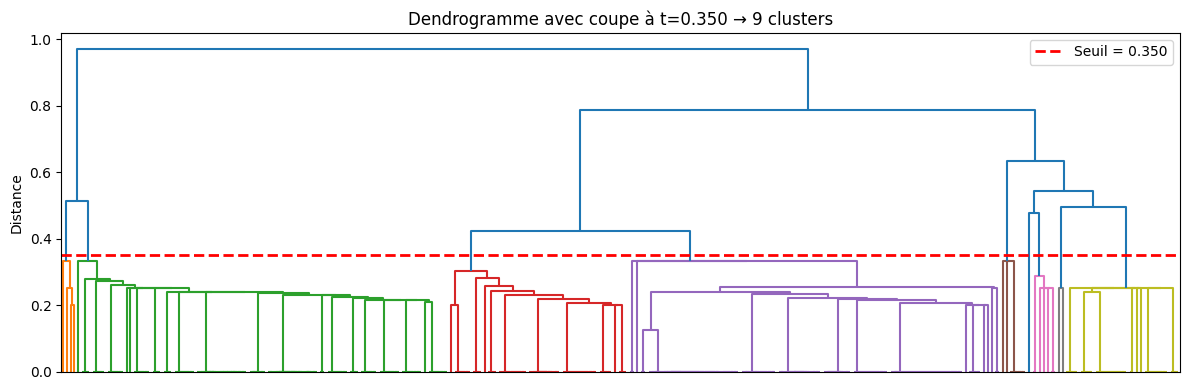

array([2, 9, 4, 4, 2, 3, 4, 2, 4, 3, 2, 4, 4, 4, 4, 2, 4, 4, 2, 4, 4, 6,
       9, 2, 9, 5, 4, 2, 3, 5, 4, 2, 2, 4, 2, 9, 4, 6, 2, 3, 3, 5, 3, 4,
       9, 2, 2, 2, 3, 2, 2, 6, 4, 3, 3, 2, 9, 6, 4, 2, 2, 4, 4, 2, 4, 9,
       2, 4, 2, 4, 9, 3, 2, 4, 2, 4, 2, 3, 2, 4, 3, 3, 3, 4, 4, 4, 2, 2,
       4, 2, 2, 2, 9, 3, 4, 2, 3, 6, 3, 9, 9, 2, 3, 4, 4, 4, 9, 9, 2, 4,
       9, 9, 2, 2, 4, 2, 3, 2, 4, 4, 3, 4, 4, 3, 4, 4, 2, 2, 4, 4, 4, 4,
       3, 2, 4, 4, 2, 9, 4, 2, 2, 2, 7, 2, 3, 9, 3, 5, 4, 4, 4, 2, 2, 2,
       2, 2, 5, 9, 4, 9, 3, 4, 2, 2, 2, 4, 3, 2, 3, 2, 2, 4, 4, 4, 4, 2,
       2, 4, 2, 3, 2, 4, 4, 4, 2, 2, 4, 5, 2, 1, 8, 3, 1, 2, 6, 2, 4, 9,
       2, 3, 2, 2, 2, 4, 3, 9, 4, 9, 4, 3, 2, 2, 3, 3, 9, 4, 2, 4, 3, 4,
       4, 4, 3, 3, 2, 4, 3, 4, 4, 4, 2, 9, 4, 2, 4, 2, 2, 4, 3, 3, 2, 4,
       4, 9, 3, 2, 2, 5, 9, 3, 2, 2, 3, 2, 2, 2, 4, 4, 4, 2, 2, 2, 2, 3,
       2, 4, 9, 3, 4, 2, 2, 4, 6, 1, 4, 4, 9, 9, 4, 3, 2, 3, 2, 4, 4, 9,
       4, 4, 2, 2, 4, 4, 9, 1, 2, 2, 4, 4, 8, 3], d

In [21]:
# ============================================================
# EXEMPLE : Coupe à différents seuils
# ============================================================

# Seuil moyen → structure principale
cut_dendrogram_and_map(0.35, show_dendrogram=True)

In [22]:
# ============================================================
# VERSION INTERACTIVE : Slider sur le seuil de coupe
# ============================================================
# COULEURS STABLES basées sur la position dans le dendrogramme

from ipywidgets import FloatSlider, Output, VBox, HBox, HTML
import ipywidgets as widgets
import matplotlib.colors as mcolors

# Créer une colormap continue basée sur la position dans le dendrogramme
# Chaque point a une "couleur de base" fixe selon sa position ACH
# Quand les clusters fusionnent, on prend la couleur moyenne

# Position normalisée de chaque point dans l'ordre ACH (0 à 1)
position_ach = np.zeros(sample_size)
for i, idx in enumerate(order_ach):
    position_ach[idx] = i / (sample_size - 1)  # 0 à 1

# Colormap spectrale pour les positions
cmap = plt.cm.get_cmap('Spectral')  # Rouge → Jaune → Vert → Bleu

def get_cluster_color(cluster_labels, clust_id, position_ach):
    """
    Calcule la couleur d'un cluster basée sur la position moyenne 
    de ses points dans le dendrogramme.
    
    Ainsi, les clusters "à gauche" seront rouges, ceux "à droite" bleus,
    et quand ils fusionnent, la couleur sera intermédiaire.
    """
    mask = cluster_labels == clust_id
    mean_pos = position_ach[mask].mean()
    return cmap(mean_pos)

# Slider pour le seuil
threshold_slider = FloatSlider(
    value=0.35,
    min=0.05,
    max=0.8,
    step=0.02,
    description='Seuil t:',
    continuous_update=False,
    layout=widgets.Layout(width='600px'),
    style={'description_width': '80px'}
)

# Affichage du nombre de clusters
n_clusters_display = HTML(value="<b>Clusters: ?</b>")
output_cut = Output()

def update_cut(change):
    """Met à jour la visualisation quand le seuil change."""
    threshold = threshold_slider.value
    
    # Couper le dendrogramme
    cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')
    n_clusters = len(set(cluster_labels))
    
    # Mettre à jour l'affichage
    n_clusters_display.value = f"<b style='font-size:16px'>→ {n_clusters} clusters</b>"
    
    with output_cut:
        output_cut.clear_output(wait=True)
        
        fig = go.Figure()
        
        # Points non échantillonnés en gris
        non_sample = np.ones(len(X), dtype=bool)
        non_sample[sample_idx_viz] = False
        fig.add_trace(go.Scattergeo(
            lat=latitudes[non_sample], lon=longitudes[non_sample],
            mode='markers', marker=dict(size=2, color='lightgray', opacity=0.1),
            hoverinfo='skip', showlegend=False
        ))
        
        # Calculer la position moyenne de chaque cluster pour trier
        cluster_positions = {}
        for clust_id in set(cluster_labels):
            mask = cluster_labels == clust_id
            cluster_positions[clust_id] = position_ach[mask].mean()
        
        # Trier les clusters par position (gauche à droite du dendrogramme)
        sorted_clusters = sorted(cluster_positions.keys(), key=lambda c: cluster_positions[c])
        
        # Points par cluster (triés par position)
        for clust_id in sorted_clusters:
            mask = cluster_labels == clust_id
            orig_idx = sample_idx_viz[mask]
            
            # Couleur basée sur la position moyenne dans le dendrogramme
            rgba = get_cluster_color(cluster_labels, clust_id, position_ach)
            hex_color = mcolors.rgb2hex(rgba[:3])
            
            # Position pour le nom
            pos_pct = cluster_positions[clust_id] * 100
            
            fig.add_trace(go.Scattergeo(
                lat=latitudes[orig_idx], lon=longitudes[orig_idx],
                mode='markers',
                marker=dict(size=8, color=hex_color, line=dict(width=0.5, color='white')),
                name=f'C{clust_id} ({len(orig_idx)}) [{pos_pct:.0f}%]',
                hoverinfo='text',
                text=[f"Cluster {clust_id}<br>Position ACH: {pos_pct:.0f}%<br>Prix: ${y[i]*100000:.0f}" 
                      for i in orig_idx]
            ))
        
        fig.update_layout(
            title=f"<b>Coupe à t={threshold:.2f} → {n_clusters} clusters</b><br>"
                  f"<sup>Couleurs stables : rouge=gauche du dendrogramme, bleu=droite</sup>",
            geo=dict(fitbounds='locations', showland=True, landcolor='#fafafa',
                     showcoastlines=True, showocean=True, oceancolor='#e8f0ff'),
            height=750,
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.01,
                       bgcolor='rgba(255,255,255,0.9)', font=dict(size=10))
        )
        fig.show()

# Connecter
threshold_slider.observe(update_cut, names='value')

# Interface
print("🎚️  EXPLORATION INTERACTIVE : Coupe du Dendrogramme")
print("=" * 55)
print("Déplacez le slider pour changer le seuil de coupe.")
print()
print("🎨 COULEURS STABLES:")
print("   • Rouge/Orange = clusters à GAUCHE du dendrogramme")
print("   • Vert/Jaune   = clusters au CENTRE")
print("   • Bleu/Violet  = clusters à DROITE du dendrogramme")
print("   → Quand 2 clusters fusionnent, la couleur devient intermédiaire")
print()

display(VBox([
    HBox([threshold_slider, n_clusters_display]),
    output_cut
]))

# Affichage initial
update_cut(None)

🎚️  EXPLORATION INTERACTIVE : Coupe du Dendrogramme
Déplacez le slider pour changer le seuil de coupe.

🎨 COULEURS STABLES:
   • Rouge/Orange = clusters à GAUCHE du dendrogramme
   • Vert/Jaune   = clusters au CENTRE
   • Bleu/Violet  = clusters à DROITE du dendrogramme
   → Quand 2 clusters fusionnent, la couleur devient intermédiaire



## 8. Synthèse et recommandations

---

## 7. Test de l'API `auto_cluster()` (nouvelle)

L'API `AntakIAAPI.auto_cluster()` unifie l'accès aux différentes méthodes de clustering :

| Méthode | Description |
|---------|-------------|
| `ensemble` | Noyaux stables (HDBSCAN+ToMATo+MGE) - **Recommandé** |
| `semisup` | Ensemble + UMAP semi-supervisé |
| `legacy` / `antakia` | Module natif antakia-ac (comme le GUI) |
| `hdbscan`, `tomato`, `mge` | Méthodes individuelles |

In [23]:
# Test direct de parcellate() avec les nouvelles méthodes

print("=" * 70)
print("TEST : Méthode ENSEMBLE (noyaux stables)")
print("=" * 70)

result_ensemble = parcellate(
    X_vs, X_es,
    method='ensemble',
    stability_threshold=0.6,
    min_parcelle_size=30,
    verbose=True
)

print(f"\n✓ Résultat Ensemble:")
print(f"  - Parcelles: {result_ensemble.n_parcelles}")
print(f"  - Score dyadique: {result_ensemble.dyadic_score:.3f}")
if hasattr(result_ensemble, 'stability_scores') and result_ensemble.stability_scores is not None:
    stab = result_ensemble.stability_scores
    print(f"  - Points très stables (>0.75): {(stab > 0.75).sum()} ({(stab > 0.75).mean()*100:.1f}%)")
    print(f"  - Points frontière (<0.5): {(stab < 0.5).sum()} ({(stab < 0.5).mean()*100:.1f}%)")

TEST : Méthode ENSEMBLE (noyaux stables)
════════════════════════════════════════════════════════════
Parcellisation Ensembliste (Noyaux Stables)
════════════════════════════════════════════════════════════
[1/4] Application de 4 méthodes...
   → hdbscan...
     2 parcelles, score=0.003
   → tomato...
     31 parcelles, score=0.000
   → mge...
     5 parcelles, score=0.000
   → consensus...
════════════════════════════════════════════════════════════
Consensus Dyadique
════════════════════════════════════════════════════════════
[1/3] Génération des partitions de base...
   VS k=3: 3 clusters
   VS k=5: 5 clusters
   VS k=8: 8 clusters
   ES k=3: 3 clusters
   ES k=5: 5 clusters
   ES k=8: 8 clusters
[2/3] Construction du consensus...

✓ Consensus terminé : 5 parcelles
     5 parcelles, score=0.000
[2/4] Calcul de la matrice de stabilité...
[3/4] Extraction des noyaux stables...
[4/4] Calcul des scores de stabilité...

✓ Ensemble terminé:
  7 parcelles
  7 noyaux stables
  Points stabl

In [24]:
# Test de la méthode SEMI-SUPERVISÉE (UMAP guidé par noyaux)

print("=" * 70)
print("TEST : Méthode SEMISUP (noyaux + UMAP semi-supervisé)")
print("=" * 70)

result_semisup = parcellate(
    X_vs, X_es,
    method='semisup',
    projection_backend='umap',  # 'umap' (stable) ou 'ivis' (deep learning)
    stability_threshold=0.7,
    supervision_weight=0.5,
    min_parcelle_size=30,
    verbose=True
)

print(f"\n✓ Résultat Semi-Supervisé:")
print(f"  - Parcelles: {result_semisup.n_parcelles}")
print(f"  - Score dyadique: {result_semisup.dyadic_score:.3f}")
print(f"  - Points supervisés: {result_semisup.n_supervised_points} ({result_semisup.supervision_ratio*100:.1f}%)")
print(f"  - Embedding shape: {result_semisup.ivis_embedding.shape}")

TEST : Méthode SEMISUP (noyaux + UMAP semi-supervisé)
════════════════════════════════════════════════════════════
Parcellisation Semi-Supervisée (UMAP)
════════════════════════════════════════════════════════════

[PHASE 1] Clustering ensembliste (noyaux stables)
--------------------------------------------------
════════════════════════════════════════════════════════════
Parcellisation Ensembliste (Noyaux Stables)
════════════════════════════════════════════════════════════
[1/4] Application de 3 méthodes...
   → hdbscan...
     2 parcelles, score=0.003
   → tomato...
     31 parcelles, score=0.000
   → mge...
     5 parcelles, score=0.000
[2/4] Calcul de la matrice de stabilité...
[3/4] Extraction des noyaux stables...
[4/4] Calcul des scores de stabilité...

✓ Ensemble terminé:
  38 parcelles
  38 noyaux stables
  Points stables (>0.75): 79.3%
  Points frontière (<0.5): 4.0%

[PHASE 2] Construction des labels partiels
--------------------------------------------------
  Points sup

Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Feb  8 10:33:07 2026 Finished embedding
  ✓ Projection terminée: (2000, 2)

[PHASE 4] Affectation finale
--------------------------------------------------
  Mode: KNN sur projection
  Points assignés : 2000/2000 (100.0%)
  Parcelles finales : 36

════════════════════════════════════════════════════════════
✓ Semi-Supervisé (UMAP) terminé
  Score dyadique : 0.000
════════════════════════════════════════════════════════════

✓ Résultat Semi-Supervisé:
  - Parcelles: 36
  - Score dyadique: 0.000
  - Points supervisés: 1585 (79.2%)
  - Embedding shape: (2000, 2)


In [ ]:
# Visualisation de la projection semi-supervisée

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Labels de cluster', 'Scores de stabilité'],
    horizontal_spacing=0.1
)

# Panel 1: Labels
emb = result_semisup.ivis_embedding
labels = result_semisup.labels

fig.add_trace(
    go.Scatter(
        x=emb[:, 0], y=emb[:, 1],
        mode='markers',
        marker=dict(
            color=labels,
            colorscale='Viridis',
            size=5,
            opacity=0.7
        ),
        name='Clusters'
    ),
    row=1, col=1
)

# Panel 2: Stabilité
stab = result_semisup.stability_scores
fig.add_trace(
    go.Scatter(
        x=emb[:, 0], y=emb[:, 1],
        mode='markers',
        marker=dict(
            color=stab,
            colorscale='RdYlGn',
            cmin=0, cmax=1,
            size=5,
            opacity=0.7,
            colorbar=dict(title='Stabilité', x=1.02)
        ),
        name='Stabilité'
    ),
    row=1, col=2
)

fig.update_layout(
    title='Projection UMAP Semi-Supervisée guidée par noyaux stables',
    height=450,
    width=900,
    showlegend=False
)
fig.show()

In [ ]:
# Comparaison finale : Legacy vs Ensemble vs Semi-supervisé

print("=" * 70)
print("COMPARAISON : Legacy vs Ensemble vs Semi-supervisé")
print("=" * 70)

# Legacy (si disponible)
try:
    result_legacy = parcellate(
        X_vs, X_es,
        method='antakia',
        n_clusters='auto',
        min_parcelle_size=30,
        verbose=False
    )
    legacy_available = True
except Exception as e:
    print(f"⚠️ Legacy non disponible: {e}")
    legacy_available = False

# Tableau comparatif
comparison_new = []

if legacy_available:
    comparison_new.append({
        'Méthode': 'Legacy (antakia-ac)',
        'Parcelles': result_legacy.n_parcelles,
        'Score Dyadique': f"{result_legacy.dyadic_score:.3f}",
        'Stabilité': '-',
        'Supervisés': '-'
    })

comparison_new.append({
    'Méthode': 'Ensemble (noyaux)',
    'Parcelles': result_ensemble.n_parcelles,
    'Score Dyadique': f"{result_ensemble.dyadic_score:.3f}",
    'Stabilité': f"{(result_ensemble.stability_scores > 0.75).mean()*100:.1f}%",
    'Supervisés': '-'
})

comparison_new.append({
    'Méthode': 'Semi-supervisé (UMAP)',
    'Parcelles': result_semisup.n_parcelles,
    'Score Dyadique': f"{result_semisup.dyadic_score:.3f}",
    'Stabilité': f"{(result_semisup.stability_scores > 0.75).mean()*100:.1f}%",
    'Supervisés': f"{result_semisup.supervision_ratio*100:.1f}%"
})

df_new = pd.DataFrame(comparison_new)
print("\n")
display(df_new)

print("\n" + "=" * 70)
print("RECOMMANDATION")
print("=" * 70)
print("""
• method='ensemble' : Robuste, identifie les noyaux stables
• method='semisup'  : Meilleure qualité, projection guidée par les noyaux
• method='legacy'   : Rapide, compatible avec le GUI

Pour l'exploration interactive : utiliser 'semisup'
Pour l'automatisation : utiliser 'ensemble'
""")

COMPARAISON : Legacy vs Ensemble vs Semi-supervisé




,Méthode,Parcelles,Score Dyadique,Stabilité,Supervisés
0,Legacy (antakia-ac),3,0.000,-,-
1,Ensemble (noyaux),7,0.000,7.1%,-
2,Semi-supervisé (UMAP),36,0.000,79.3%,79.2%



RECOMMANDATION

• method='ensemble' : Robuste, identifie les noyaux stables
• method='semisup'  : Meilleure qualité, projection guidée par les noyaux
• method='legacy'   : Rapide, compatible avec le GUI

Pour l'exploration interactive : utiliser 'semisup'
Pour l'automatisation : utiliser 'ensemble'



In [ ]:
# Tableau final avec ensemble
print("="*80)
print("SYNTHÈSE FINALE")
print("="*80)

# Calculer métriques dyadiques pour ensemble
from sklearn.metrics import silhouette_score

mask = ensemble_labels >= 0
if len(set(ensemble_labels[mask])) >= 2:
    sil_vs_ens = silhouette_score(X_vs[mask], ensemble_labels[mask])
    sil_es_ens = silhouette_score(X_es[mask], ensemble_labels[mask])
    dyadic_ens = 2 * sil_vs_ens * sil_es_ens / (sil_vs_ens + sil_es_ens + 1e-10)
else:
    sil_vs_ens = sil_es_ens = dyadic_ens = 0

# Ajouter métriques ensemble
comparison_data.append({
    'Méthode': 'Ensemble (Noyaux)',
    'Parcelles': len(set(ensemble_labels)),
    'Silhouette VS': f"{sil_vs_ens:.3f}",
    'Silhouette ES': f"{sil_es_ens:.3f}",
    'Score Dyadique': f"{dyadic_ens:.3f}",
    'Consistance': '-',
    'Bruit (%)': f"{(ensemble_labels == -1).sum() / len(ensemble_labels) * 100:.1f}"
})

df_final = pd.DataFrame(comparison_data)
df_final = df_final.sort_values('Score Dyadique', ascending=False)

display(df_final)

print("\n" + "="*80)
print("RECOMMANDATIONS")
print("="*80)
print("""
1. MODE AUTOMATIQUE (meilleure suggestion robuste) :
   → Utiliser la méthode Ensemble (Noyaux Stables)
   → Les points avec stabilité > 0.75 sont fiables
   → Les points avec stabilité < 0.5 sont à la frontière

2. MODE EXPERT (correction manuelle) :
   → Interface pour :
     • Fusionner des parcelles
     • Diviser une parcelle
     • Réassigner des points frontière
     • Ajuster les seuils de stabilité

3. STRATÉGIE DE RAFFINEMENT :
   → Partir des noyaux stables comme "graines"
   → Appliquer GRANITE pour minimiser les interactions
   → Les points frontière guident les subdivisions
""")

SYNTHÈSE FINALE


,Méthode,Parcelles,Silhouette VS,Silhouette ES,Score Dyadique,Consistance,Bruit (%)
1,HDBSCAN Dyadique,2,0.002,0.241,0.003,-0.000,50.3
0,AntakIA Native,3,-0.024,0.104,0.000,-0.009,5.8
2,ToMATo Dyadique,31,-0.202,-0.204,0.000,0.004,0.0
3,MGE,4,-0.210,0.078,0.000,-0.007,0.0
4,Consensus,4,-0.218,0.147,0.000,-0.007,0.0
5,Ensemble (Noyaux),15,-0.601,-0.224,-0.327,-,0.0



RECOMMANDATIONS

1. MODE AUTOMATIQUE (meilleure suggestion robuste) :
   → Utiliser la méthode Ensemble (Noyaux Stables)
   → Les points avec stabilité > 0.75 sont fiables
   → Les points avec stabilité < 0.5 sont à la frontière

2. MODE EXPERT (correction manuelle) :
   → Interface pour :
     • Fusionner des parcelles
     • Diviser une parcelle
     • Réassigner des points frontière
     • Ajuster les seuils de stabilité

3. STRATÉGIE DE RAFFINEMENT :
   → Partir des noyaux stables comme "graines"
   → Appliquer GRANITE pour minimiser les interactions
   → Les points frontière guident les subdivisions



---

## Conclusion

Ce notebook démontre :

1. **6 méthodes de parcellisation** comparées sur le même dataset
2. **Métriques dyadiques** (VS × ES) pour évaluation objective
3. **Méthode Ensemble** qui identifie les **noyaux stables**
4. **Visualisation géographique** des résultats
5. **Carte de stabilité** pour identifier les points frontière

### Prochaines étapes

- Intégrer la méthode Ensemble dans `antakia.parcellation`
- Ajouter GRANITE avec interactions pour raffinement
- Développer l'interface de correction manuelle